# Stability & Linearization (Control-Theory View)

We move beyond forward simulation and analyze local dynamics around a steady state.

For a dynamical system

$$
\dot{x} = f(x),
$$

a fixed point $x^*$ satisfies

$$
f(x^*) = 0.
$$

Linearizing around $x^*$ gives

$$
\delta \dot{x} = J(x^*) \, \delta x,
$$

where $J(x^*)$ is the Jacobian matrix evaluated at the fixed point.

The eigenvalues of $J(x^*)$ determine:

- **Local stability** — the system is stable if all eigenvalues have negative real parts.
- **Dominant time scales** — the magnitudes of the real parts set how fast perturbations decay.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from tibs.models.gene_expression import GeneExpression

In [12]:
def fd_jacobian(f, x, eps=1e-6):
    x = np.asarray(x, dtype=float)
    n = x.size
    fx = np.asarray(f(x), dtype=float)
    J = np.zeros((n, n), dtype=float)
    for i in range(n):
        dx = np.zeros_like(x)
        dx[i] = eps
        f_plus = np.asarray(f(x + dx), dtype=float)
        f_minus = np.asarray(f(x - dx), dtype=float)
        J[:, i] = (f_plus - f_minus) / (2 * eps)
    if fx.shape != (n,):
        raise ValueError(f"f(x) must return shape {(n,)}, got {fx.shape}")
    return J

def newton_fixed_point(f, x0, tol=1e-10, max_iter=50, damping=1.0, eps=1e-6):
    x = np.asarray(x0, dtype=float).copy()
    for k in range(max_iter):
        fx = np.asarray(f(x), dtype=float)
        res = float(np.linalg.norm(fx, ord=2))
        if res < tol:
            return x, {"converged": True, "iters": k, "residual": res}
        J = fd_jacobian(f, x, eps=eps)
        try:
            dx = np.linalg.solve(J, -fx)
        except np.linalg.LinAlgError:
            dx = np.linalg.lstsq(J, -fx, rcond=None)[0]
        x = x + damping * dx
    fx = np.asarray(f(x), dtype=float)
    res = float(np.linalg.norm(fx, ord=2))
    return x, {"converged": False, "iters": max_iter, "residual": res}

In [13]:
model = GeneExpression()
p = model.parameters()

def f(x):
    # Model expects rhs(t, x, p)
    return model.rhs(t=0.0, x=np.asarray(x, dtype=float), p=p)

print("Parameters:")
for k, v in p.items():
    print(f"  {k}: {v}")

Parameters:
  k_tx: 1.0
  k_tl: 5.0
  gamma_m: 0.2
  gamma_p: 0.05


## Fixed point \(x*\)

For the default gene expression model (mRNA → protein with linear degradation),
we can often write down the steady state analytically and also verify it numerically.

In [14]:
# Analytical fixed point for the (linear) gene expression model:
# m* = k_tx / gamma_m
# p* = (k_tl / gamma_p) * m*
m_star = p["k_tx"] / p["gamma_m"]
prot_star = (p["k_tl"] / p["gamma_p"]) * m_star
x_star_analytic = np.array([m_star, prot_star], dtype=float)

print("Analytic x* =", x_star_analytic)
print("f(x*) =", f(x_star_analytic))
print("||f(x*)|| =", np.linalg.norm(f(x_star_analytic)))

Analytic x* = [  5. 500.]
f(x*) = [0. 0.]
||f(x*)|| = 0.0


In [15]:
x_star_newton, info = newton_fixed_point(f, x0=np.array([0.0, 0.0]))
print("Newton x*  =", x_star_newton)
print("Info       =", info)
print("Difference =", x_star_newton - x_star_analytic)

Newton x*  = [  5. 500.]
Info       = {'converged': True, 'iters': 2, 'residual': 3.552713678800501e-15}
Difference = [ 0.00000000e+00 -1.13686838e-13]


## Jacobian and eigenvalues

We compute the Jacobian \(J(x*)\) numerically (finite differences).
Eigenvalues tell us local stability:
- stable if all real parts < 0
- unstable if any real part > 0

In [16]:
J = fd_jacobian(f, x_star_analytic)
eigvals = np.linalg.eigvals(J)

print("J(x*):\n", J)
print("\nEigenvalues:", eigvals)

stable = np.all(np.real(eigvals) < 0)
print("\nLocally stable?", stable)

# characteristic time scales from real parts (if stable)
real_parts = np.real(eigvals)
taus = np.where(real_parts < 0, -1.0 / real_parts, np.inf)
print("Approx time constants (hours or model time units):", taus)

J(x*):
 [[-0.2   0.  ]
 [ 5.   -0.05]]

Eigenvalues: [-0.05 -0.2 ]

Locally stable? True
Approx time constants (hours or model time units): [20.00000048  5.        ]


## Phase portrait (2D)

We plot the vector field and mark the fixed point.
This is the quickest “systems intuition” visual.

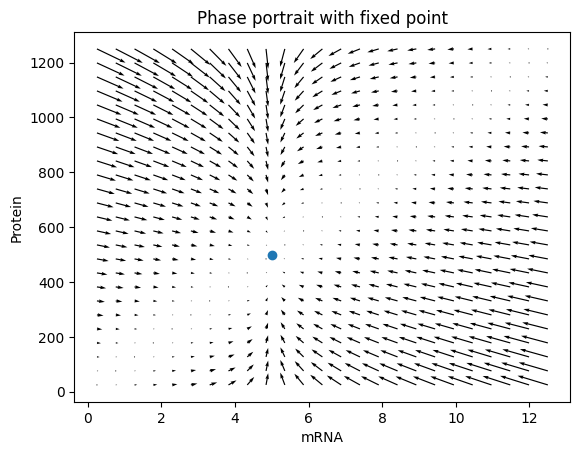

In [17]:
m0, p0 = x_star_analytic

m_vals = np.linspace(max(0.0, m0 * 0.05), m0 * 2.5, 25)
p_vals = np.linspace(max(0.0, p0 * 0.05), p0 * 2.5, 25)
M, Pgrid = np.meshgrid(m_vals, p_vals)

U = np.zeros_like(M)
V = np.zeros_like(Pgrid)

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        dm, dp = f([M[i, j], Pgrid[i, j]])
        U[i, j] = dm
        V[i, j] = dp

plt.figure()
plt.quiver(M, Pgrid, U, V, angles="xy")
plt.plot([m0], [p0], marker="o")
plt.xlabel("mRNA")
plt.ylabel("Protein")
plt.title("Phase portrait with fixed point")
plt.show()

## Interpretation 

- The steady state scales **linearly** with transcription$k_{tx}$ and translation $k_{tl}$
- The eigenvalues set the **relaxation time scales**: how fast the system returns to steady state after perturbations.
- In this model, those time scales are dominated by degradation rates ($\gamma_m$, $\gamma_p$).
